<a href="https://colab.research.google.com/github/Killeryoung/ML/blob/main/%D0%9B%D0%A0_2_2_%D0%93%D1%83%D1%80%D0%BA%D0%BE_%D0%A4%D0%86%D0%A2_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 2


# Завдання 2
У роботі виконується очищення та аналіз набору даних Titanic:
розмір і типи даних, пропущені значення, дублікати, вибір ознак,
кодування статі, описова статистика, аналіз виживання за статтю,
класом, віком і тарифом, а також кореляційна теплова карта.

## 1. Імпорт бібліотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Завантаження набору даних

In [23]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Визначити розмір датасета

In [3]:
print("Розмір датасета:", df.shape)
print("Кількість рядків:", df.shape[0])
print("Кількість стовпців:", df.shape[1])


Розмір датасета: (891, 12)
Кількість рядків: 891
Кількість стовпців: 12


## 4. Визначити типи даних

In [4]:
print(df.dtypes)
print()
df.info()


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(

## 5. Перевірити наявність пропущених значень

In [5]:
print("Пропущені значення до обробки:")
print(df.isnull().sum())


Пропущені значення до обробки:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## 6. Обробка пропущених значень

Для числових стовпців пропущені значення замінюємо медіаною.
Для текстових стовпців, якщо вони є, використовується найчастіше значення.


In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

object_cols = df.select_dtypes(include="object").columns
for col in object_cols:
    if df[col].isnull().any():
        mode = df[col].mode()
        if not mode.empty:
            df[col] = df[col].fillna(mode[0])

print("Пропущені значення після заповнення:")
print(df.isnull().sum())


Пропущені значення після заповнення:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


## 7. Перевірити наявність дублікатів.

In [7]:
duplicates = df.duplicated().sum()
print("Кількість дублікатів:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Дублікати видалено.")


Кількість дублікатів: 0


## 8. Ще раз перевірити пропущені значення.

In [8]:
print(df.isnull().sum())
print("\nЗагальна кількість пропущених значень:", df.isnull().sum().sum())


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Загальна кількість пропущених значень: 0


## 9. Сформувати датасет з обраними стовпцями.

In [9]:
selected_columns = ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']
data = df[selected_columns].copy()

data.head()


,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


## 10. Перевірити унікальні значення Sex та замінити стать на 0 і 1.

In [10]:
print("Унікальні значення Sex:", data['Sex'].unique())

data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

print("\nПісля кодування:")
print(data['Sex'].unique())
data.head()


Унікальні значення Sex: ['male' 'female']

Після кодування:
[0 1]


,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


## 11. Описова статистика.



In [11]:
data.describe()


,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


## 12. Перевірити, що пропущених даних немає.

In [12]:
print(data.isnull().sum())
print("\nУсього пропущених значень:", data.isnull().sum().sum())


Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
dtype: int64

Усього пропущених значень: 0


## 13. Вивести 5 перших рядків.

In [13]:
data.head()


,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


## 14. Вивести 5 останніх рядків.

In [14]:
data.tail()


,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


## 15. Аналіз виживання залежно від статі.

In [15]:
survival_by_sex = data.groupby('Sex')['Survived'].mean() * 100

print("Відсоток виживання за статтю:")
print("Чоловіки (0):", round(survival_by_sex.get(0, np.nan), 2), "%")
print("Жінки (1):", round(survival_by_sex.get(1, np.nan), 2), "%")

if survival_by_sex.get(1, 0) > survival_by_sex.get(0, 0):
    print("\nВисновок: жінки мали значно вищий відсоток виживання, ніж чоловіки.")
else:
    print("\nВисновок: чоловіки мали вищий або такий самий відсоток виживання.")


Відсоток виживання за статтю:
Чоловіки (0): 18.89 %
Жінки (1): 74.2 %

Висновок: жінки мали значно вищий відсоток виживання, ніж чоловіки.


## 16. Відсоток виживання для кожного класу Pclass.

In [16]:
survival_by_class = data.groupby('Pclass')['Survived'].mean() * 100
print(survival_by_class.round(2))

best_class = survival_by_class.idxmax()
print(f"\nНайвищий рівень виживання мав {best_class}-й клас: {survival_by_class.max():.2f}%.")


Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

Найвищий рівень виживання мав 1-й клас: 62.96%.


## 17. Середній вік тих, хто вижив, і тих, хто не вижив.

In [17]:
age_survival = data.groupby('Survived')['Age'].mean()
print(age_survival.round(2))

difference = abs(age_survival.loc[1] - age_survival.loc[0])
print(f"\nРізниця середнього віку: {difference:.2f} року/років.")

if difference < 5:
    print("Висновок: різниця середнього віку невелика, тому за цим показником вік не демонструє сильного впливу на виживання.")
else:
    print("Висновок: між групами є помітна різниця середнього віку.")


Survived
0    30.03
1    28.29
Name: Age, dtype: float64

Різниця середнього віку: 1.74 року/років.
Висновок: різниця середнього віку невелика, тому за цим показником вік не демонструє сильного впливу на виживання.


## 18. Групи за рівнями тарифу Fare та рівень виживання.

In [18]:
data['FareGroup'] = pd.qcut(
    data['Fare'],
    q=4,
    labels=['Низький', 'Середній', 'Високий', 'Дуже високий'],
    duplicates='drop'
)

fare_survival = data.groupby('FareGroup', observed=False)['Survived'].mean() * 100
print(fare_survival.round(2))

print("\nВисновок:")
if fare_survival.iloc[-1] > fare_survival.iloc[0]:
    print("У групах з вищим тарифом рівень виживання загалом вищий.")
else:
    print("За отриманими даними вищий тариф не показав вищого рівня виживання.")


FareGroup
Низький         19.73
Середній        30.36
Високий         45.50
Дуже високий    58.11
Name: Survived, dtype: float64

Висновок:
У групах з вищим тарифом рівень виживання загалом вищий.


## 19. Аналіз класу та тарифу.

In [19]:
fare_by_class = data.groupby('Pclass')['Fare'].mean()
print("Середній тариф за класами:")
print(fare_by_class.round(2))

ratio = fare_by_class.max() / fare_by_class.min()
print(f"\nНайбільший середній тариф приблизно у {ratio:.2f} раза більший за найменший.")
print("Висновок: тарифи між класами суттєво відрізняються; пасажири вищого класу в середньому платили більше.")


Середній тариф за класами:
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

Найбільший середній тариф приблизно у 6.15 раза більший за найменший.
Висновок: тарифи між класами суттєво відрізняються; пасажири вищого класу в середньому платили більше.


## 20. Як пов'язано середній вік пасажирів з виживанням?

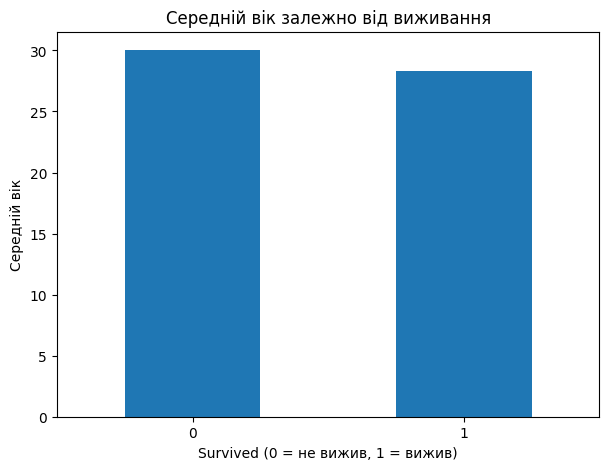

Survived
0    30.03
1    28.29
Name: Age, dtype: float64


In [20]:
mean_age = data.groupby('Survived')['Age'].mean()

plt.figure(figsize=(7, 5))
mean_age.plot(kind='bar')
plt.title('Середній вік залежно від виживання')
plt.xlabel('Survived (0 = не вижив, 1 = вижив)')
plt.ylabel('Середній вік')
plt.xticks(rotation=0)
plt.show()

print(mean_age.round(2))


## 21. Розрахувати виживаність для класів і статі.

In [21]:
survival_class_sex = (
    data.groupby(['Pclass', 'Sex'])['Survived']
        .mean()
        .mul(100)
        .unstack()
)

survival_class_sex.columns = ['Чоловіки (0)', 'Жінки (1)']
print(survival_class_sex.round(2))


        Чоловіки (0)  Жінки (1)
Pclass                         
1              36.89      96.81
2              15.74      92.11
3              13.54      50.00


## 22. Теплова карта кореляції.

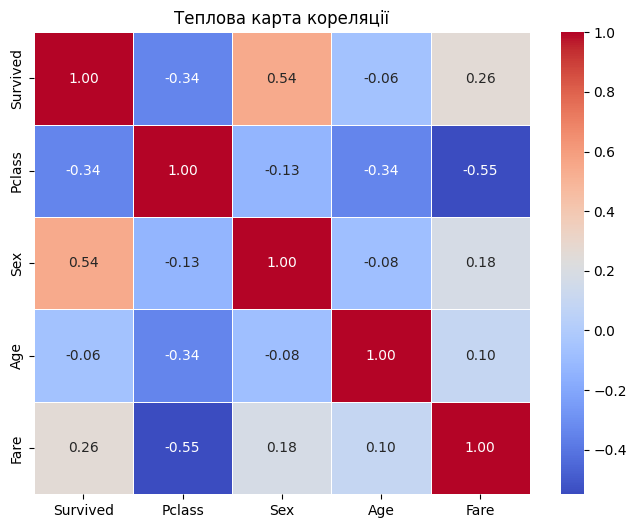

In [22]:
corr_data = data[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_data.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Теплова карта кореляції')
plt.show()


## Висновок

У ході роботи було виконано попередню обробку та аналіз набору даних Titanic.
Перевірено розмір, типи даних, пропущені значення та дублікати. Пропущені
числові значення були замінені медіаною. Для подальшого аналізу обрано
ознаки `Survived`, `Pclass`, `Sex`, `Age` та `Fare`, а стать перетворено
у числову бінарну ознаку.

Було досліджено залежність виживання від статі, класу пасажира, віку та
вартості квитка. Також розраховано рівень виживання одночасно за класом
і статтю та побудовано теплову карту кореляції. Точні числові результати
і висновки виводяться безпосередньо після запуску відповідних комірок.
